# Sharp regression discontinuity with scikit-learn models

In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ExpSineSquared, WhiteKernel
from sklearn.linear_model import LinearRegression

import causalpy as cp

In [2]:
%config InlineBackend.figure_format = 'retina'

## Load data

In [3]:
data = cp.load_data("rd")
data.head(5)

,x,y,treated
0,-0.989008,-0.252433,False
1,-0.984119,-0.050974,False
2,-0.964955,-0.216572,False
3,-0.962408,-0.204497,False
4,-0.944821,-0.354276,False


## Linear, main-effects model

In [4]:
result = cp.RegressionDiscontinuity(
    data,
    formula="y ~ 1 + x + treated",
    model=LinearRegression(),
    treatment_threshold=0.5,
)

/Users/benjamv/git/CausalPy/causalpy/experiments/base.py:235: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.


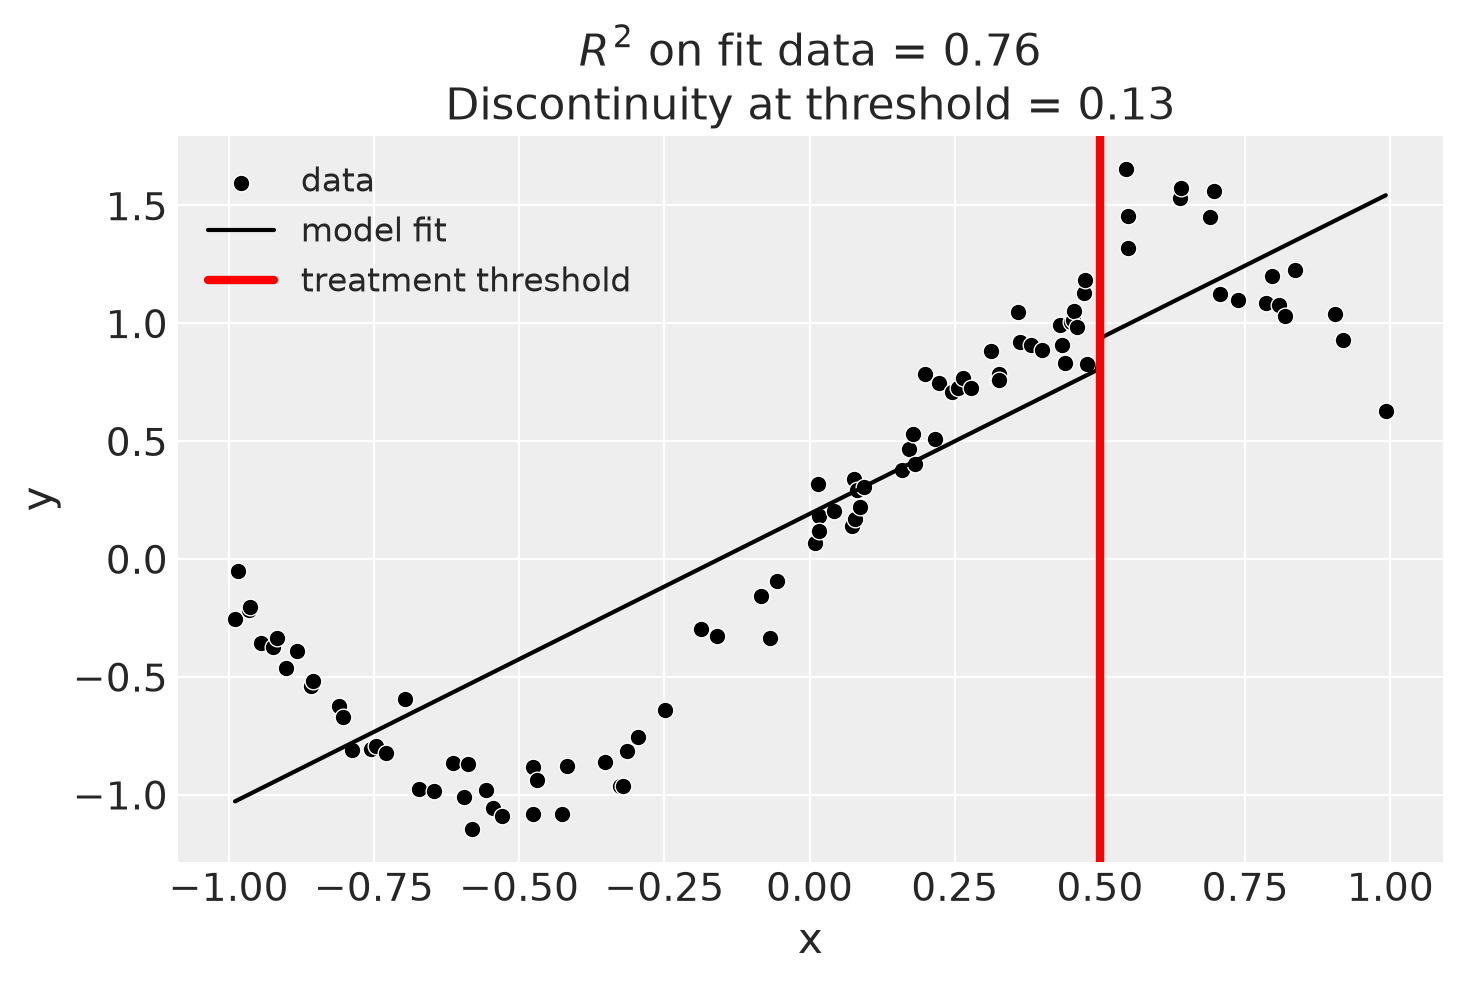

In [5]:
fig, ax = result.plot()

In [6]:
result.summary(round_to=3)

Regression Discontinuity experiment
Formula: y ~ 1 + x + treated
Running variable: x
Threshold on running variable: 0.5
Bandwidth: inf
Donut hole: 0.0
Observations used for fit: 100

Results:
Discontinuity at threshold = 0.13


Model coefficients:
  Intercept      	     0.191
  treated[T.True]	     0.129
  x              	      1.23


We can get nicely formatted tables from our integration with the [maketables](https://github.com/py-econometrics/maketables) package.

In [7]:
from maketables import ETable

ETable(result, coef_fmt="b:.3f")

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x15690ecf0>

## Linear, main-effects, and interaction model

In [8]:
result = cp.RegressionDiscontinuity(
    data,
    formula="y ~ 1 + x + treated + x:treated",
    model=LinearRegression(),
    treatment_threshold=0.5,
)

/Users/benjamv/git/CausalPy/causalpy/experiments/base.py:235: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.


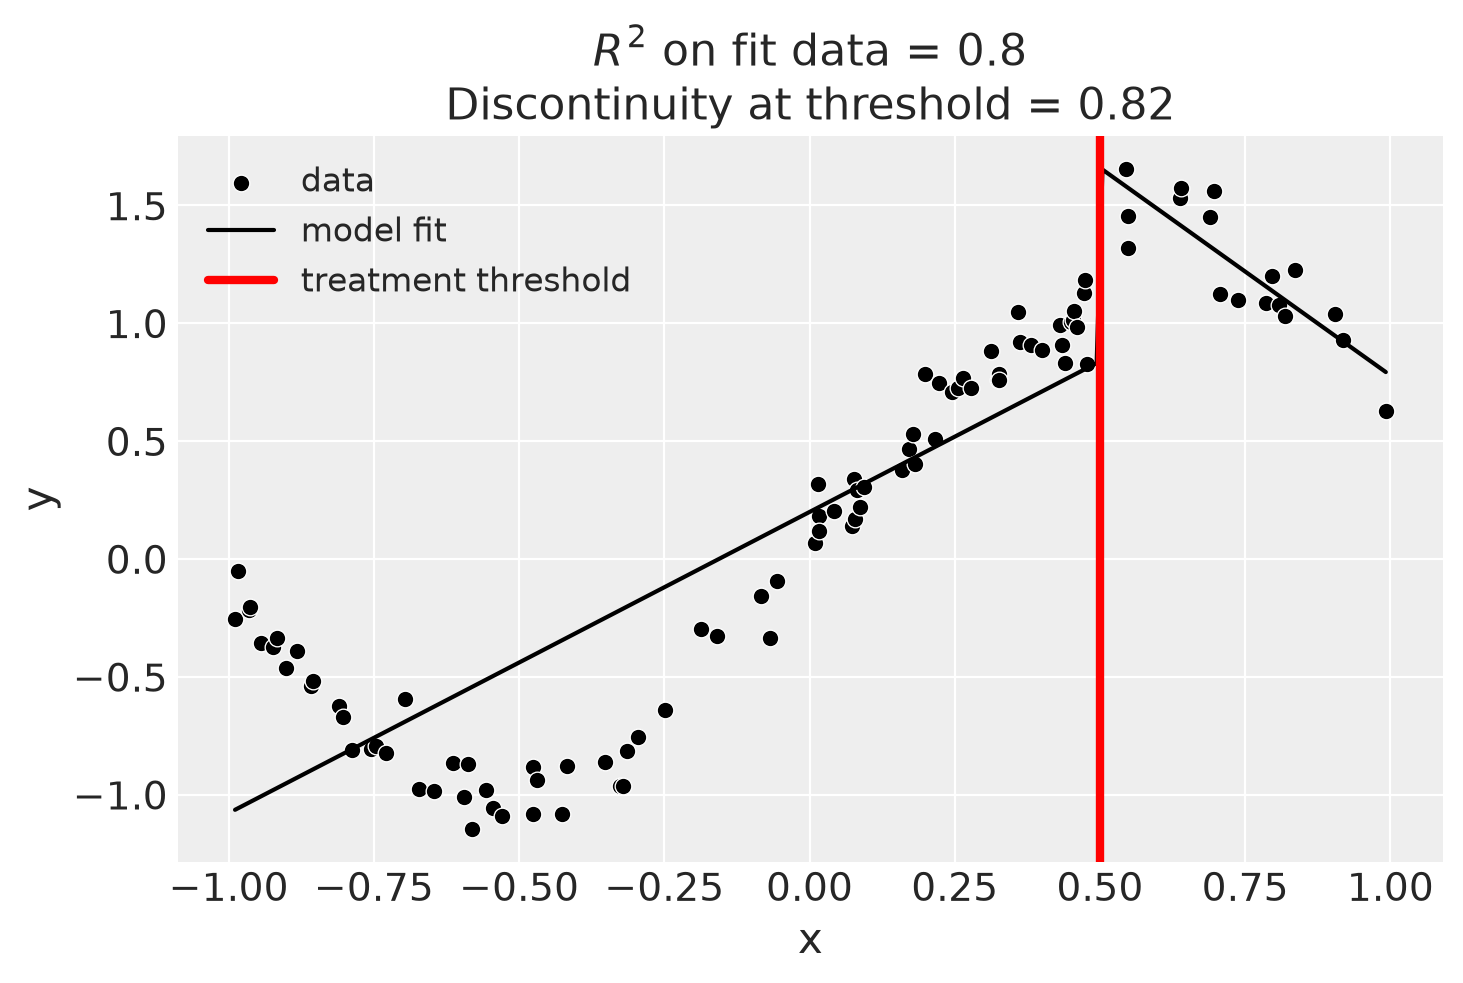

In [9]:
result.plot();

Though we can see that this does not give a good fit of the data almost certainly overestimates the discontinuity at threshold.

In [10]:
result.summary(round_to=3)

Regression Discontinuity experiment
Formula: y ~ 1 + x + treated + x:treated
Running variable: x
Threshold on running variable: 0.5
Bandwidth: inf
Donut hole: 0.0
Observations used for fit: 100

Results:
Discontinuity at threshold = 0.82


Model coefficients:
  Intercept        	       0.2
  treated[T.True]  	      2.34
  x                	      1.28
  x:treated[T.True]	     -3.04


## Using a bandwidth

One way how we could deal with this is to use the `bandwidth` kwarg. This will only fit the model to data within a certain bandwidth of the threshold. If $x$ is the running variable, then the model will only be fitted to data where $threshold - bandwidth \le x \le threshold + bandwidth$.

/Users/benjamv/git/CausalPy/causalpy/experiments/base.py:235: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.


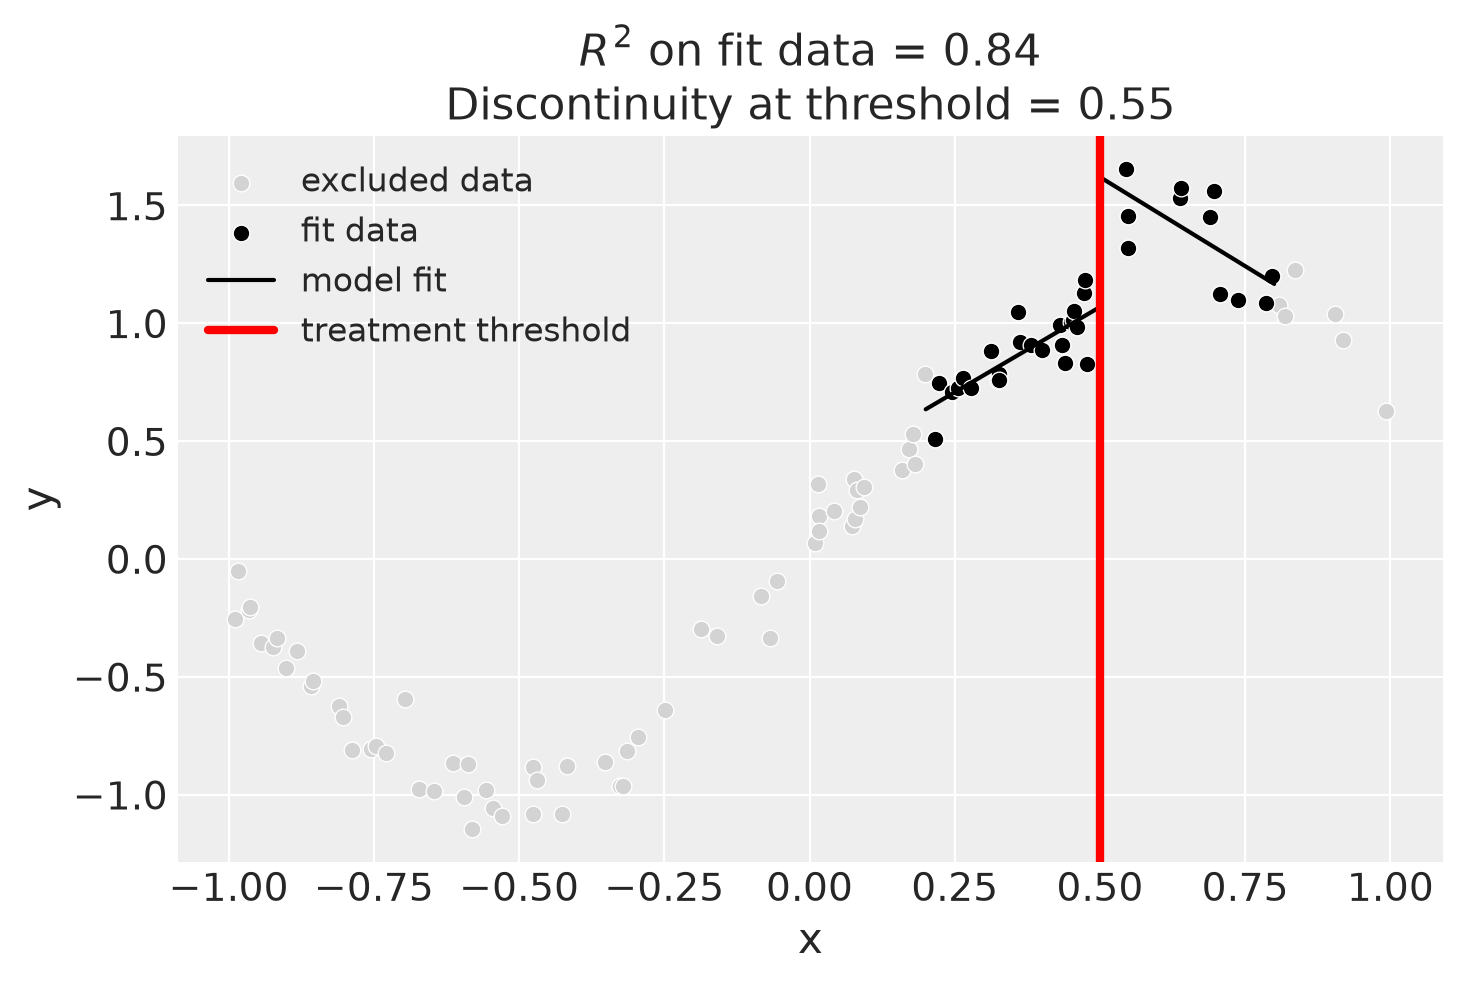

In [11]:
result = cp.RegressionDiscontinuity(
    data,
    formula="y ~ 1 + x + treated + x:treated",
    model=LinearRegression(),
    treatment_threshold=0.5,
    bandwidth=0.3,
)

result.plot();

We could even go crazy and just fit intercepts for the data close to the threshold. But clearly this will involve more estimation error as we are using less data.

/Users/benjamv/git/CausalPy/causalpy/experiments/base.py:235: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.


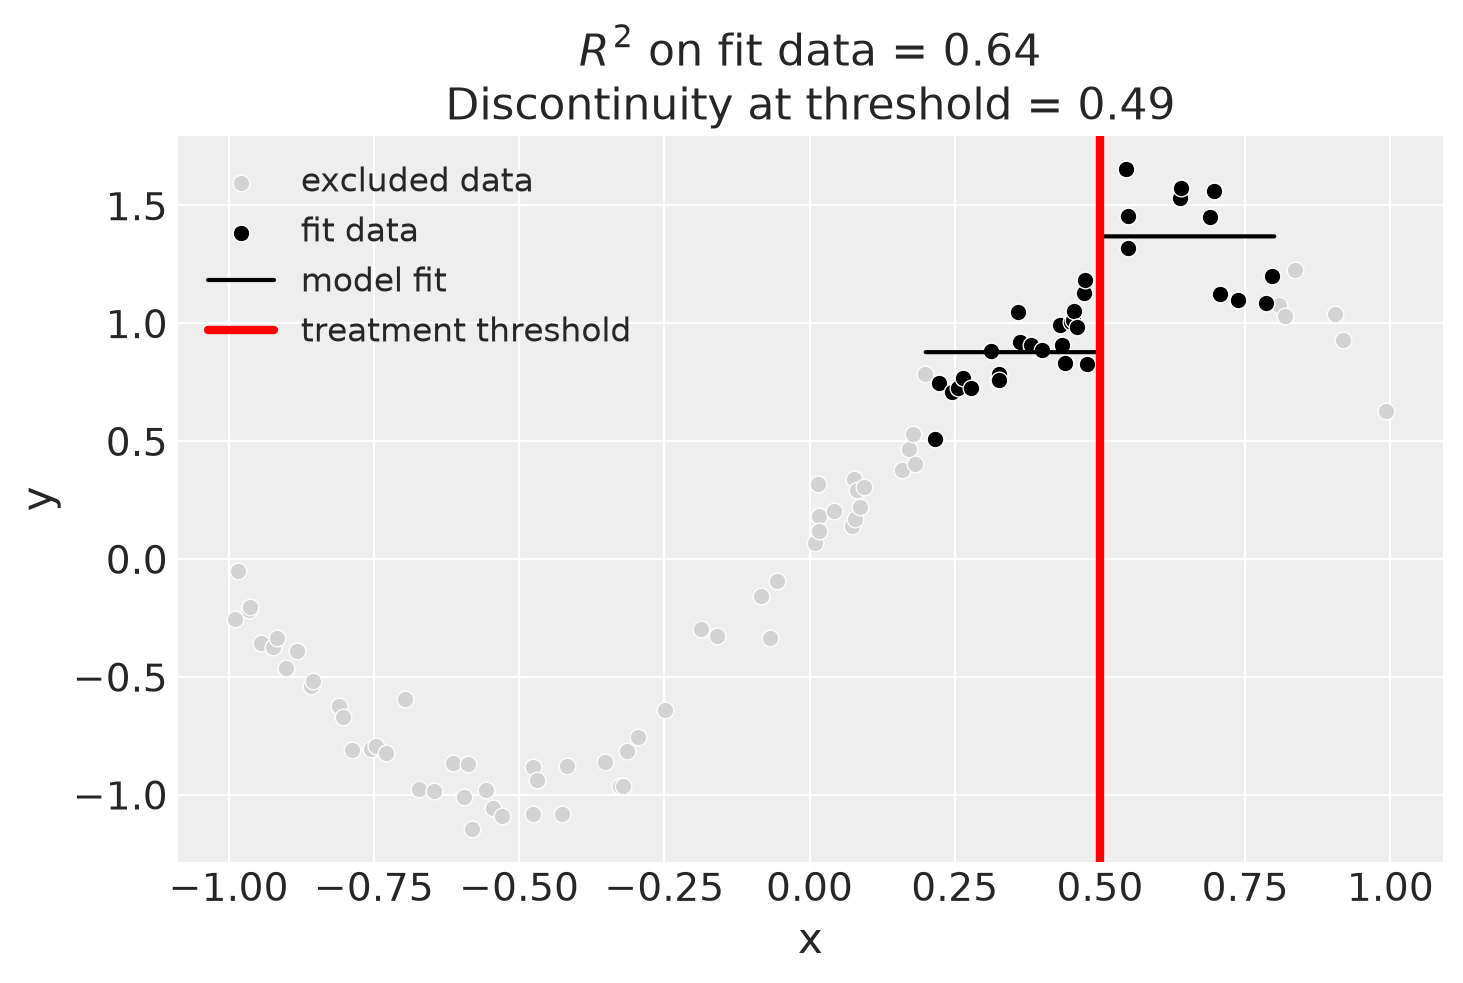

In [12]:
result = cp.RegressionDiscontinuity(
    data,
    formula="y ~ 1 + treated",
    model=LinearRegression(),
    treatment_threshold=0.5,
    bandwidth=0.3,
)

result.plot();

## Using Gaussian Processes

Now we will demonstrate how to use a scikit-learn model. 

In [13]:
kernel = 1.0 * ExpSineSquared(1.0, 5.0) + WhiteKernel(1e-1)
result = cp.RegressionDiscontinuity(
    data,
    formula="y ~ 1 + x + treated",
    model=GaussianProcessRegressor(kernel=kernel),
    treatment_threshold=0.5,
)

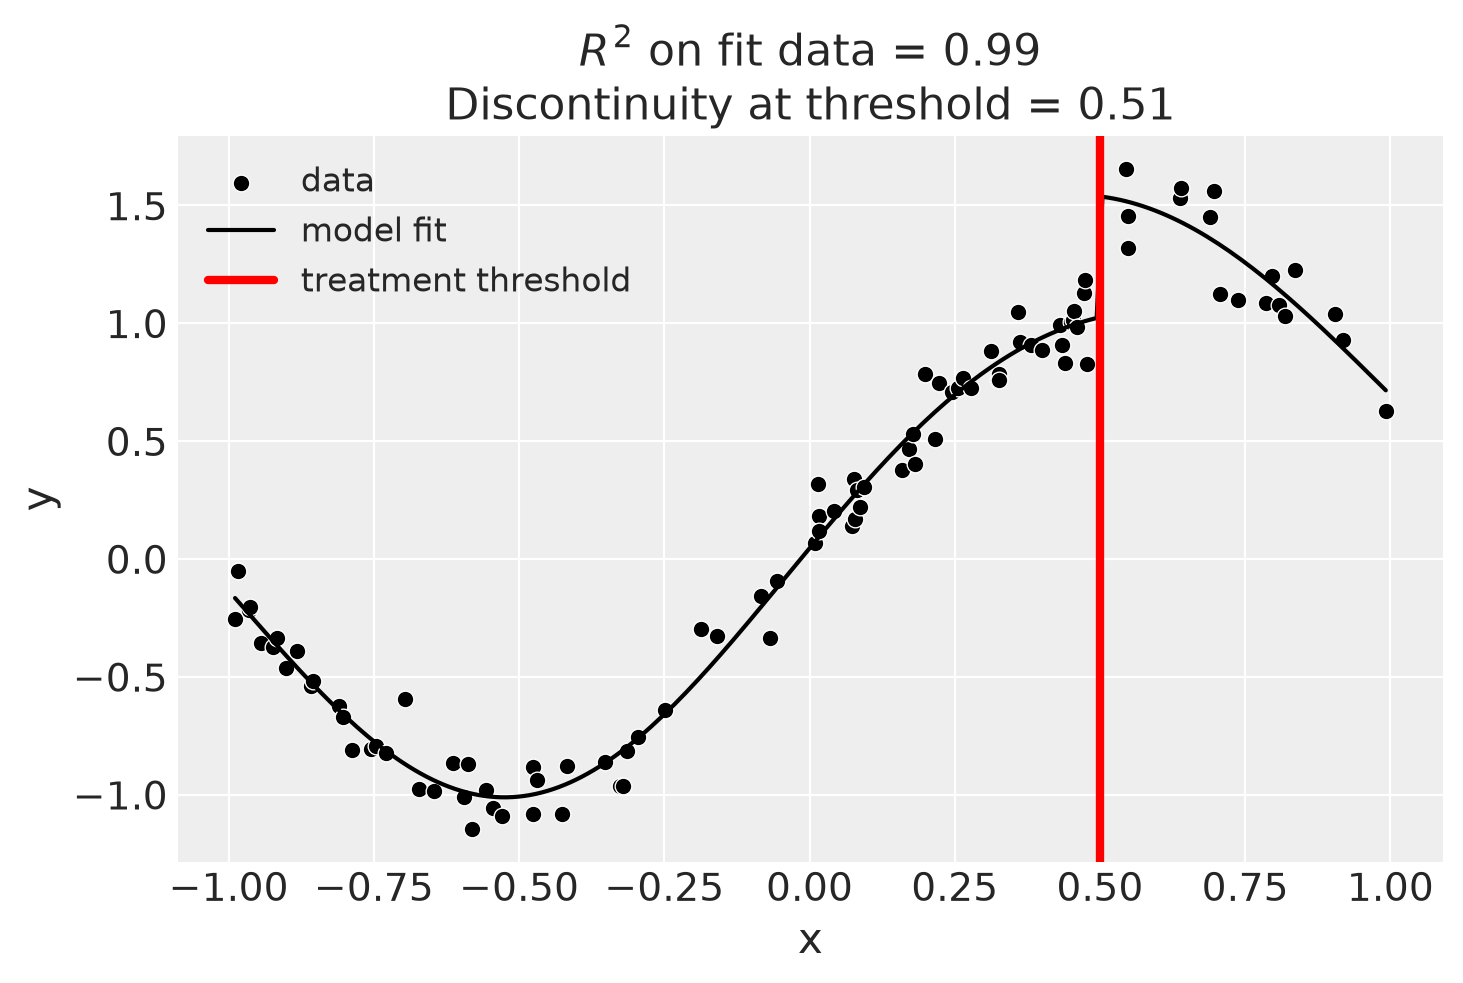

In [14]:
fig, ax = result.plot()

## Using basis splines

In [15]:
result = cp.RegressionDiscontinuity(
    data,
    formula="y ~ 1 + bs(x, df=6) + treated",
    model=LinearRegression(),
    treatment_threshold=0.5,
)

/Users/benjamv/git/CausalPy/causalpy/experiments/base.py:235: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.


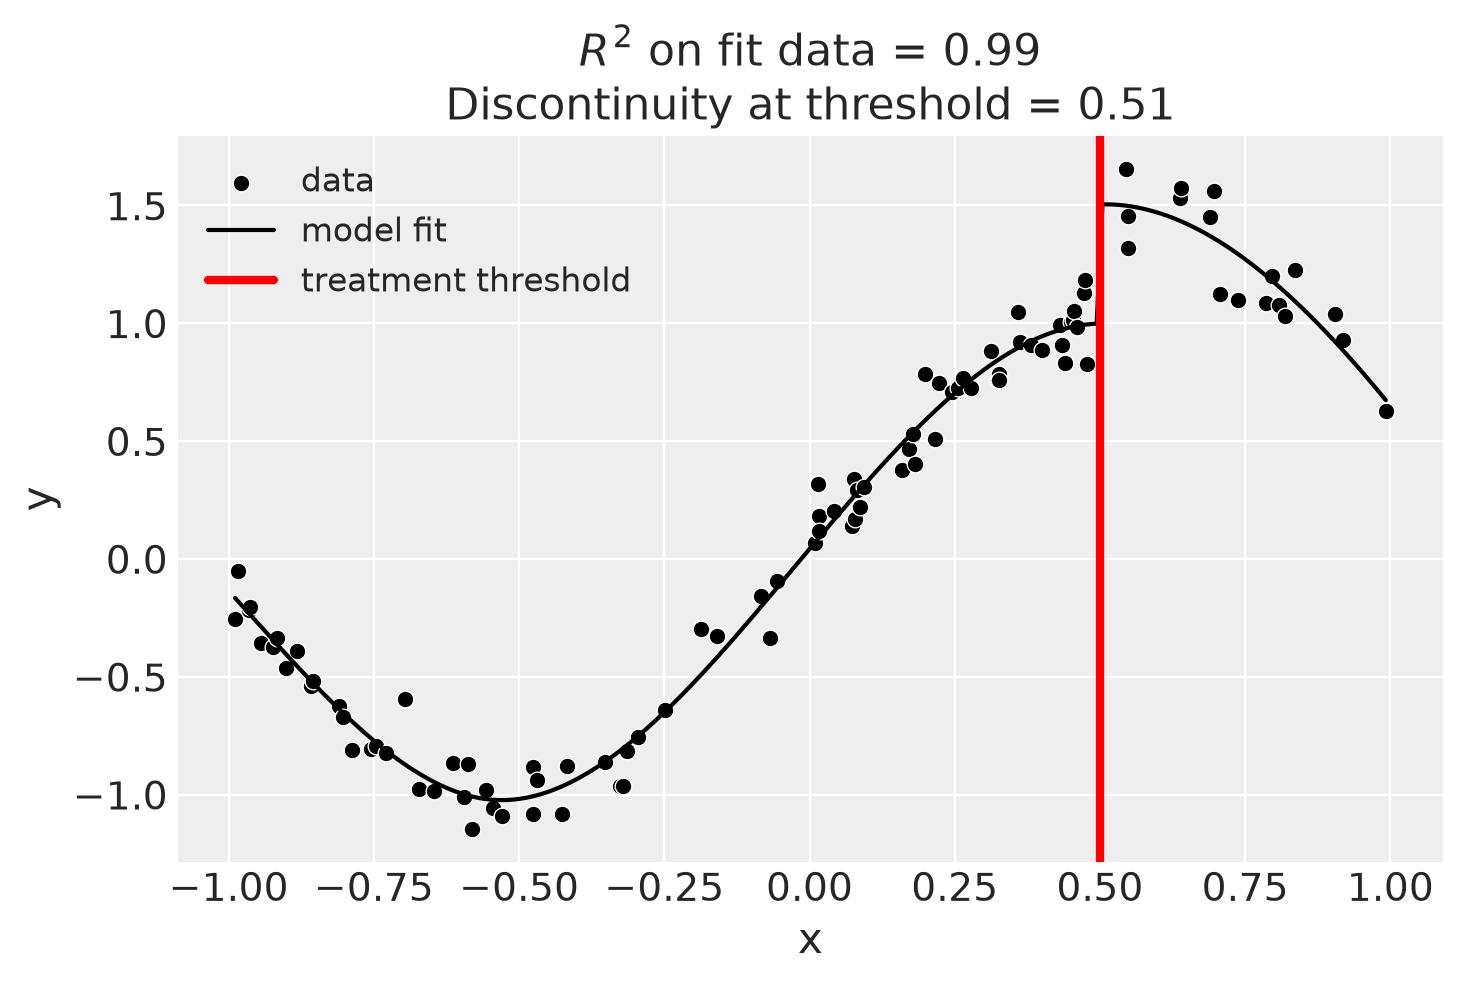

In [16]:
fig, ax = result.plot()

In [17]:
result.summary(round_to=3)

Regression Discontinuity experiment
Formula: y ~ 1 + bs(x, df=6) + treated
Running variable: x
Threshold on running variable: 0.5
Bandwidth: inf
Donut hole: 0.0
Observations used for fit: 100

Results:
Discontinuity at threshold = 0.51


Model coefficients:
  Intercept      	    -0.165
  treated[T.True]	     0.505
  bs(x, df=6)[0] 	    -0.401
  bs(x, df=6)[1] 	     -1.42
  bs(x, df=6)[2] 	     0.268
  bs(x, df=6)[3] 	      1.51
  bs(x, df=6)[4] 	     0.892
  bs(x, df=6)[5] 	     0.334


## Effect Summary Reporting

For decision-making, you often need a concise summary of the causal effect. The `effect_summary()` method provides a decision-ready report with key statistics. Note that for Regression Discontinuity, the effect is a single scalar (the discontinuity at the threshold), similar to Difference-in-Differences.

:::{note}
**OLS vs PyMC Models**: When using OLS models (scikit-learn), the `effect_summary()` provides **confidence intervals** and **p-values** (frequentist inference), rather than the posterior distributions, HDI intervals, and tail probabilities provided by PyMC models (Bayesian inference). OLS tables include: mean, CI_lower, CI_upper, and p_value, but do not include median, tail probabilities (P(effect>0)), or ROPE probabilities.
:::


In [18]:
# Generate effect summary for the final model (basis splines)
stats = result.effect_summary()
stats.table

,mean,ci_lower,ci_upper,p_value
discontinuity,0.505527,0.273907,0.737147,0.000037


In [19]:
# View the prose summary
print(stats.text)

The discontinuity at threshold was 0.51 (95% CI [0.27, 0.74]), with a p-value of 0.000.


In [20]:
# You can specify the direction of interest (e.g., testing for an increase)
stats_increase = result.effect_summary(direction="increase")
stats_increase.table

,mean,ci_lower,ci_upper,p_value
discontinuity,0.505527,0.273907,0.737147,0.000037
